# Classification

Is the second most popular supervised learning task.

# MNIST

In this project we will be using **MNIST** dataset, that contains 70 000 images of handwritten digits. Each picture labeled with integer it represents.

It's often called the "Hello World!" of Machine Learning.

**SKlearn** provides simple fetching of popular datasets:

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np

mnist = fetch_openml("mnist_784", version=1, as_frame=False) # https://stackoverflow.com/questions/67544370/keyerror-while-fetching-mnist-data
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

> `fetch_openml()` by default returns DataFrame on 12.05.2025, set `as_frame=False` to get NumPy array.

- DESCR key describing the dataset
- A data key containing an array with one row per instance and one column per
feature
- A target key containing an array with the labels

In [2]:
X: np.ndarray = mnist["data"]
y: np.ndarray = mnist["target"]
print(X.shape, y.shape)

(70000, 784) (70000,)


Wow! Each integer has 784 features, that's because each picture contains of $ 28 \times 28 $ pixels. And each feature value represents intensity, from 0 *(white)* to 255 *(black)*

To be able to display pixels, you need to reshape vector to a $ 28 \times 28 $ array and display in **MatPlotLib Imshow** that allows to create pictures from 2d arrays.


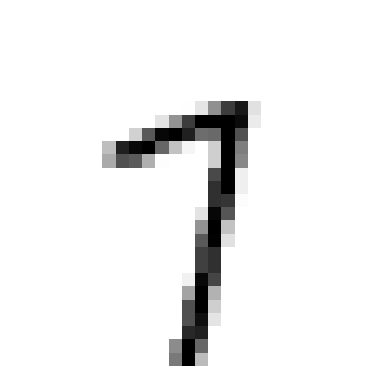

In [3]:
import matplotlib.pyplot as plt

some_digit = X[42]
some_digit_image = some_digit.reshape(28, 28)

some_digit_label = y[42]

plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()


Looks like 1 or 7. Let's check it's label:

In [4]:
print(some_digit_label)
print(type(some_digit_label))

7
<class 'str'>


That's 7! But label type is string, let's parce it to integer.

In [5]:
y = y.astype(np.uint8)

But firstly, let's create test and train sets. The **MNIST** dataset is already shuffled and easily can be split into 60k length train and 10k length test sets.

In [6]:
X_train, X_test = X[:60_000], X[60_000:]
y_train, y_test = y[:60_000], y[60_000:]

# Training a Binary Classifier

Let's break down this problem to a simpler one, binary classifier. That is capable of distinguishing just two cases - **8** and **not 8**.

Let's take every vector that represents 8:

In [7]:
y_train_8 = y_train == 8 # [False, True, False, False]
y_test_8 = y_test == 5

y_train_8

array([False, False, False, ..., False, False,  True], shape=(60000,))

Let's pick a classifier and train it. We will start with **Stochastic Gradient Descent** using Sklearn **SGQClassifier**. The classifier is capable dealing with large dataset effectively. Because it's deal with training instances independently *(which is well suited for **online learning**)*.

In [8]:
from sklearn.linear_model import SGDClassifier

sgd = SGDClassifier(random_state=42)
sgd.fit(X_train, y_train_8)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


In [9]:
k = 20

results = sgd.predict([x for x in X_train[:k]])
labels = y_train[:k]

for i in range(k):
    print(f"Label: {labels[i]} Result: {results[i]}")

Label: 5 Result: False
Label: 0 Result: False
Label: 4 Result: False
Label: 1 Result: False
Label: 9 Result: False
Label: 2 Result: False
Label: 1 Result: False
Label: 3 Result: False
Label: 1 Result: False
Label: 4 Result: False
Label: 3 Result: False
Label: 5 Result: True
Label: 3 Result: False
Label: 6 Result: False
Label: 1 Result: False
Label: 7 Result: False
Label: 2 Result: False
Label: 8 Result: True
Label: 6 Result: False
Label: 9 Result: False


As we can see, model correctly guessed one 8, but made mistake classifying 5 as an 8.

# Performance Measures

## Self implemented **Cross-Validation**

If you need more control over your cross cal, you can implement it with your own hand:

In [10]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3, random_state=42, shuffle=True)

for train_index, test_index in skfolds.split(X_train, y_train_8):
    train_X, train_y = X_train[train_index], y_train_8[train_index]
    test_X, test_y = X_train[test_index], y_train_8[test_index]

    sgd_clf: SGDClassifier = clone(sgd)
    sgd_clf.fit(train_X, train_y)
    results = sgd_clf.predict(test_X)

    correct = 0
    for i, res in enumerate(results):
        if res == test_y[i]:
            correct += 1

    print(correct / len(results))

0.9365
0.92665
0.8386


Let's use known before `cross_val` from **SKLearn** to evaluate how our model perform.

In [11]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd, X_train, y_train_8, cv=3, scoring="accuracy")

array([0.909  , 0.9286 , 0.88285])

Wow! Over 90% accuracy, that's impressing. Until you realise that chance of guessing is one number out of 10 is 8 90%.

Let's try to implement a very dumb model to compare results.

In [15]:
from sklearn.base import BaseEstimator

class Not8Classifier(BaseEstimator):
    def fit(self, X, y):
        return self
    def predict(self, X):
        return np.zeros((len(X), 1), dtype=bool) # Array of False values

not8 = Not8Classifier()

cross_val_score(not8, X_train, y_train_8, cv=3, scoring="accuracy")

array([0.9039 , 0.9031 , 0.90045])

That's right, 90% accuracy, this is simply because only about 10% of the images are 8's. So you will always be right about 90& of thet time.

This demonstrates why **accuracy** isn't preferred perf. measure for classifying. Especially with **skewed** datasets, where some data appear more frequently that the others.

## Confusion Matrix

This approach is a much better way. The general idea is to count the number of times instances of class A are
classified as class

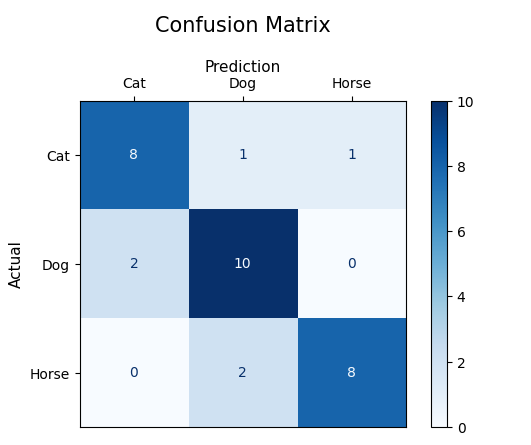

In [19]:
from sklearn.model_selection import cross_val_predict

y_train_predict = cross_val_predict(sgd, X_train, y_train_8, cv=3)

from sklearn.metrics import confusion_matrix

confusion_matrix(y_train_8, y_train_predict)

array([[50006,  4143],
       [ 1448,  4403]])

Only two rows, because our classifier can only return boolean prediction.

Each row in a confusion matrix represents an **actual class**, while each column represents a **predicted class**. The first row of this matrix considers non-5 images _(the negative class)_: 53,057 of them were correctly classified as non-5s _(they are called true
negatives)_, while the remaining 1,522 were wrongly classified as 5s _(false positives)_.
The second row considers the images of 5s _(the positive class)_: 1,325 were wrongly
classified as non-5s _(false negatives)_

If we had a perfect model, every cell in confusion matrix would be full of zeros, except for main diagonal.

In [20]:
y_train_perfect_predictions = y_train_8 # A Perfect model

confusion_matrix(y_train_8, y_train_perfect_predictions)

array([[54149,     0],
       [    0,  5851]])

Our confusion matrix figure: _(taken from the book)_
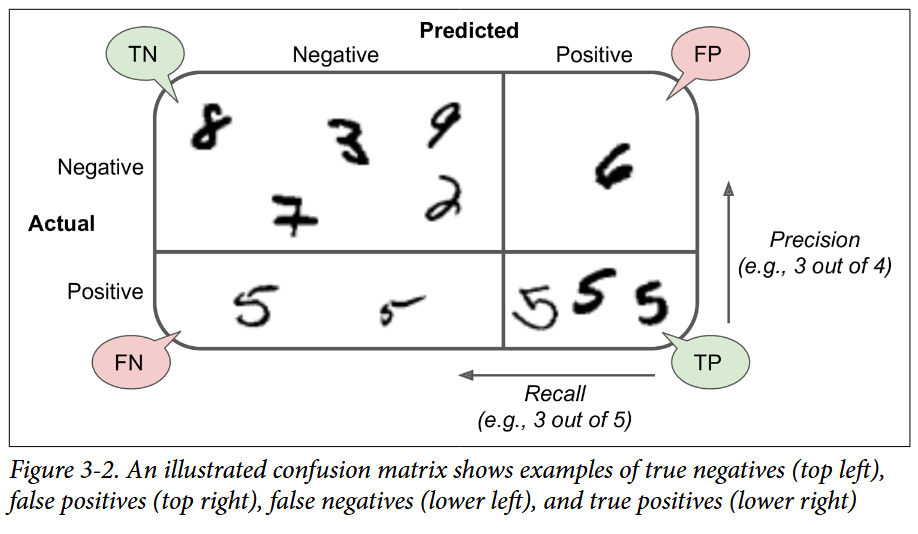

## Precision and Recall

Precision - how precise your models.
> Out of predicted 8s, how many were correct?

Recall - ratio of how many 8s your model found.
> How many of the real 8s the model found.


In [21]:
from sklearn.metrics import recall_score, precision_score

print(precision_score(y_train_8, y_train_predict)) # 4403 / (4403 + 1448) | from the conf. matrix
print(recall_score(y_train_8, y_train_predict))

0.515211794991809
0.7525209365920356


As we can see, our predictor doesn't look shiny at all. It gets only 51% percent of 8s correctly, and classified as 8 only 75% of the 8s.

If we combine these two metrix into one, we will get **F1 Score** - _harmonic mean_
$$
\begin{align}
F_1 &= 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} = \frac{TP}{TP + \frac{FN + FP}{2}}
\end{align}
$$

In [22]:
from sklearn.metrics import f1_score

print(f1_score(y_train_8, y_train_predict))

0.6116552059456831


Regular mean treats all values equally, the harmonic mean gives more weight to low values. To get high **F1 Score**, both precision and recall must be high.